### Kernel-size comparison code (MR vs DR)

Paired rows: 112
Unique num_kernels: [500, 1000, 5000, 10000]


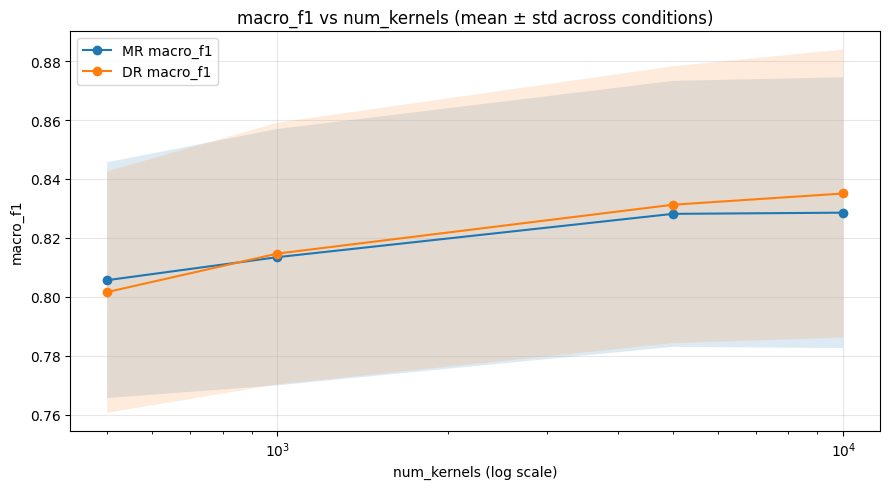

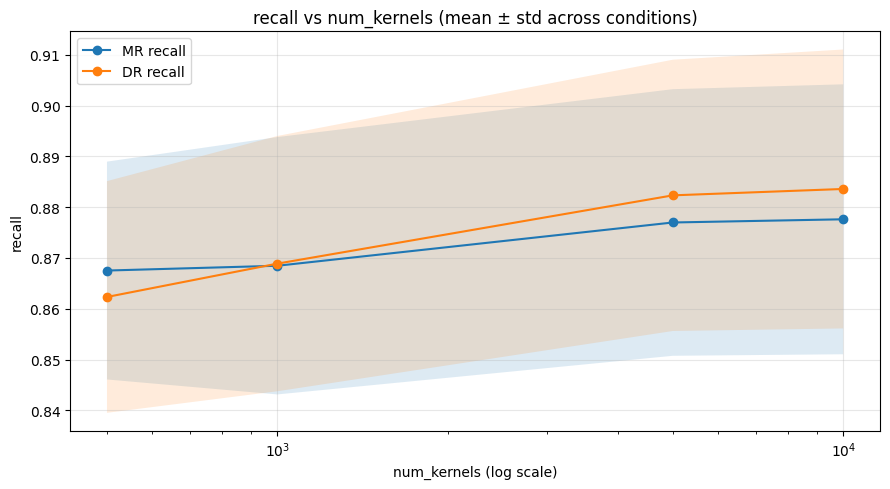

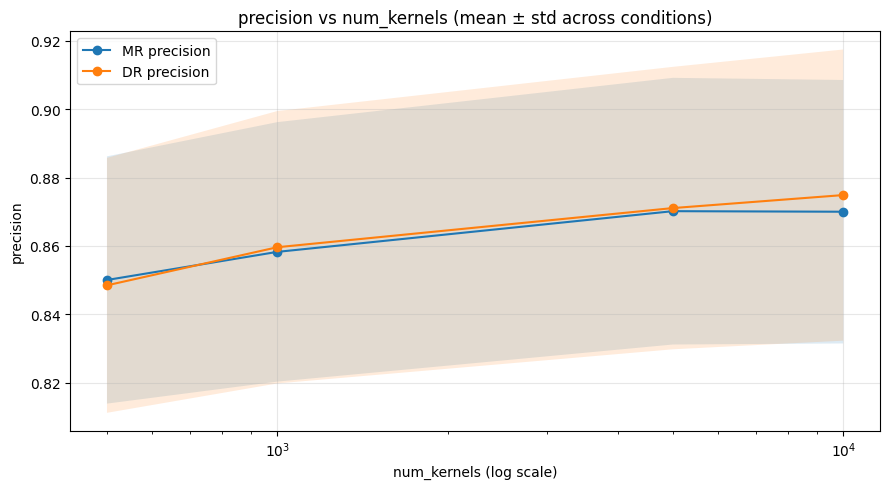

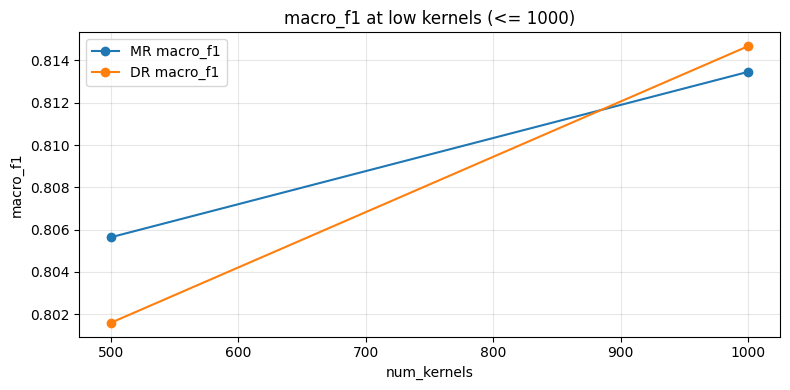

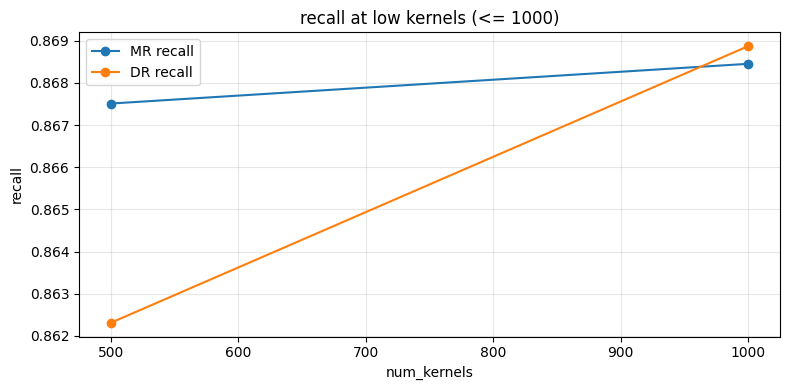

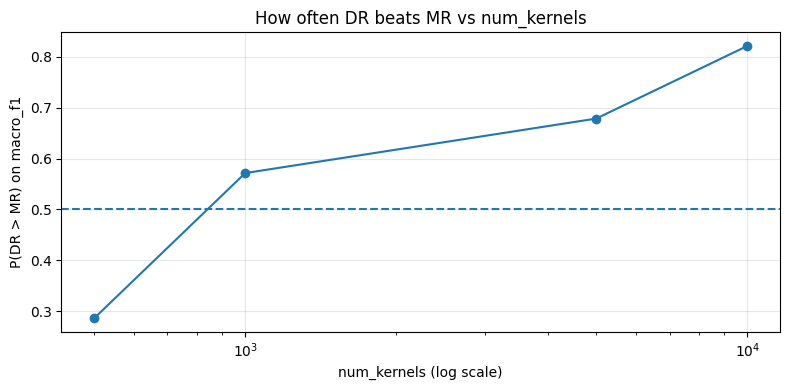


=== Low-kernel summary ===
   num_kernels  mr_macro_f1_mean  dr_macro_f1_mean  delta_mean  dr_win_rate  \
0          500          0.805639          0.801596   -0.004043     0.285714   
1         1000          0.813461          0.814676    0.001214     0.571429   

    n  
0  28  
1  28  


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_dr=pd.read_csv('res/dr_classifxn.csv')
df_mr=pd.read_csv('res/mr_classifxn.csv')


# Ensure correct dtypes
for df in [df_mr, df_dr]:
    df["num_kernels"] = df["num_kernels"].astype(int)

# Conditions to match models fairly
ID_COLS = ["drop_thermal_and_tof_options", "use_raw_imus", "use_physics_features", "cebra_output_dims", "num_kernels"]

# Merge MR and DR on same condition + same kernel count
df_kernel_cmp = pd.merge(
    df_mr, df_dr,
    on=ID_COLS,
    suffixes=("_mr", "_dr"),
    how="inner"
)

print("Paired rows:", len(df_kernel_cmp))
print("Unique num_kernels:", sorted(df_kernel_cmp["num_kernels"].unique()))

# -----------------------------
# 1) Mean performance vs num_kernels
# -----------------------------
def plot_metric_vs_kernels(metric="macro_f1"):
    g = df_kernel_cmp.groupby("num_kernels", as_index=False).agg(
        mr_mean=(f"{metric}_mr", "mean"),
        dr_mean=(f"{metric}_dr", "mean"),
        mr_std=(f"{metric}_mr", "std"),
        dr_std=(f"{metric}_dr", "std"),
        n=("num_kernels", "count")
    ).sort_values("num_kernels")

    plt.figure(figsize=(9, 5))
    plt.plot(g["num_kernels"], g["mr_mean"], marker="o", label=f"MR {metric}")
    plt.plot(g["num_kernels"], g["dr_mean"], marker="o", label=f"DR {metric}")

    plt.fill_between(g["num_kernels"], g["mr_mean"] - g["mr_std"], g["mr_mean"] + g["mr_std"], alpha=0.15)
    plt.fill_between(g["num_kernels"], g["dr_mean"] - g["dr_std"], g["dr_mean"] + g["dr_std"], alpha=0.15)

    plt.xscale("log")
    plt.xlabel("num_kernels (log scale)")
    plt.ylabel(metric)
    plt.title(f"{metric} vs num_kernels (mean ± std across conditions)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric_vs_kernels("macro_f1")
plot_metric_vs_kernels("recall")
plot_metric_vs_kernels("precision")

# -----------------------------
# Add comparison columns FIRST
# -----------------------------
df_kernel_cmp["dr_better_macro_f1"] = (df_kernel_cmp["macro_f1_dr"] > df_kernel_cmp["macro_f1_mr"]).astype(int)
df_kernel_cmp["delta_macro_f1"] = df_kernel_cmp["macro_f1_dr"] - df_kernel_cmp["macro_f1_mr"]


# -----------------------------
# 2) Low-kernel zoom (<= 1000)
# -----------------------------
df_low = df_kernel_cmp[df_kernel_cmp["num_kernels"] <= 1000].copy()

def plot_low_kernels(metric="macro_f1"):
    g = df_low.groupby("num_kernels", as_index=False).agg(
        mr_mean=(f"{metric}_mr", "mean"),
        dr_mean=(f"{metric}_dr", "mean"),
    ).sort_values("num_kernels")

    plt.figure(figsize=(8, 4))
    plt.plot(g["num_kernels"], g["mr_mean"], marker="o", label=f"MR {metric}")
    plt.plot(g["num_kernels"], g["dr_mean"], marker="o", label=f"DR {metric}")
    plt.xlabel("num_kernels")
    plt.ylabel(metric)
    plt.title(f"{metric} at low kernels (<= 1000)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_low_kernels("macro_f1")
plot_low_kernels("recall")

# -----------------------------
# 3) Who wins at each kernel size?
# -----------------------------
df_kernel_cmp["dr_better_macro_f1"] = (df_kernel_cmp["macro_f1_dr"] > df_kernel_cmp["macro_f1_mr"]).astype(int)

win_rate = df_kernel_cmp.groupby("num_kernels", as_index=False).agg(
    dr_win_rate=("dr_better_macro_f1", "mean"),
    n=("dr_better_macro_f1", "count")
).sort_values("num_kernels")

plt.figure(figsize=(8, 4))
plt.plot(win_rate["num_kernels"], win_rate["dr_win_rate"], marker="o")
plt.axhline(0.5, linestyle="--")
plt.xscale("log")
plt.xlabel("num_kernels (log scale)")
plt.ylabel("P(DR > MR) on macro_f1")
plt.title("How often DR beats MR vs num_kernels")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Best model at low kernels (summary table)
# -----------------------------
df_kernel_cmp["delta_macro_f1"] = df_kernel_cmp["macro_f1_dr"] - df_kernel_cmp["macro_f1_mr"]

best_low = (
    df_low.groupby("num_kernels", as_index=False)
    .agg(
        mr_macro_f1_mean=("macro_f1_mr", "mean"),
        dr_macro_f1_mean=("macro_f1_dr", "mean"),
        delta_mean=("delta_macro_f1", "mean"),
        dr_win_rate=("dr_better_macro_f1", "mean"),
        n=("delta_macro_f1", "count")
    )
    .sort_values("num_kernels")
)

print("\n=== Low-kernel summary ===")
print(best_low)

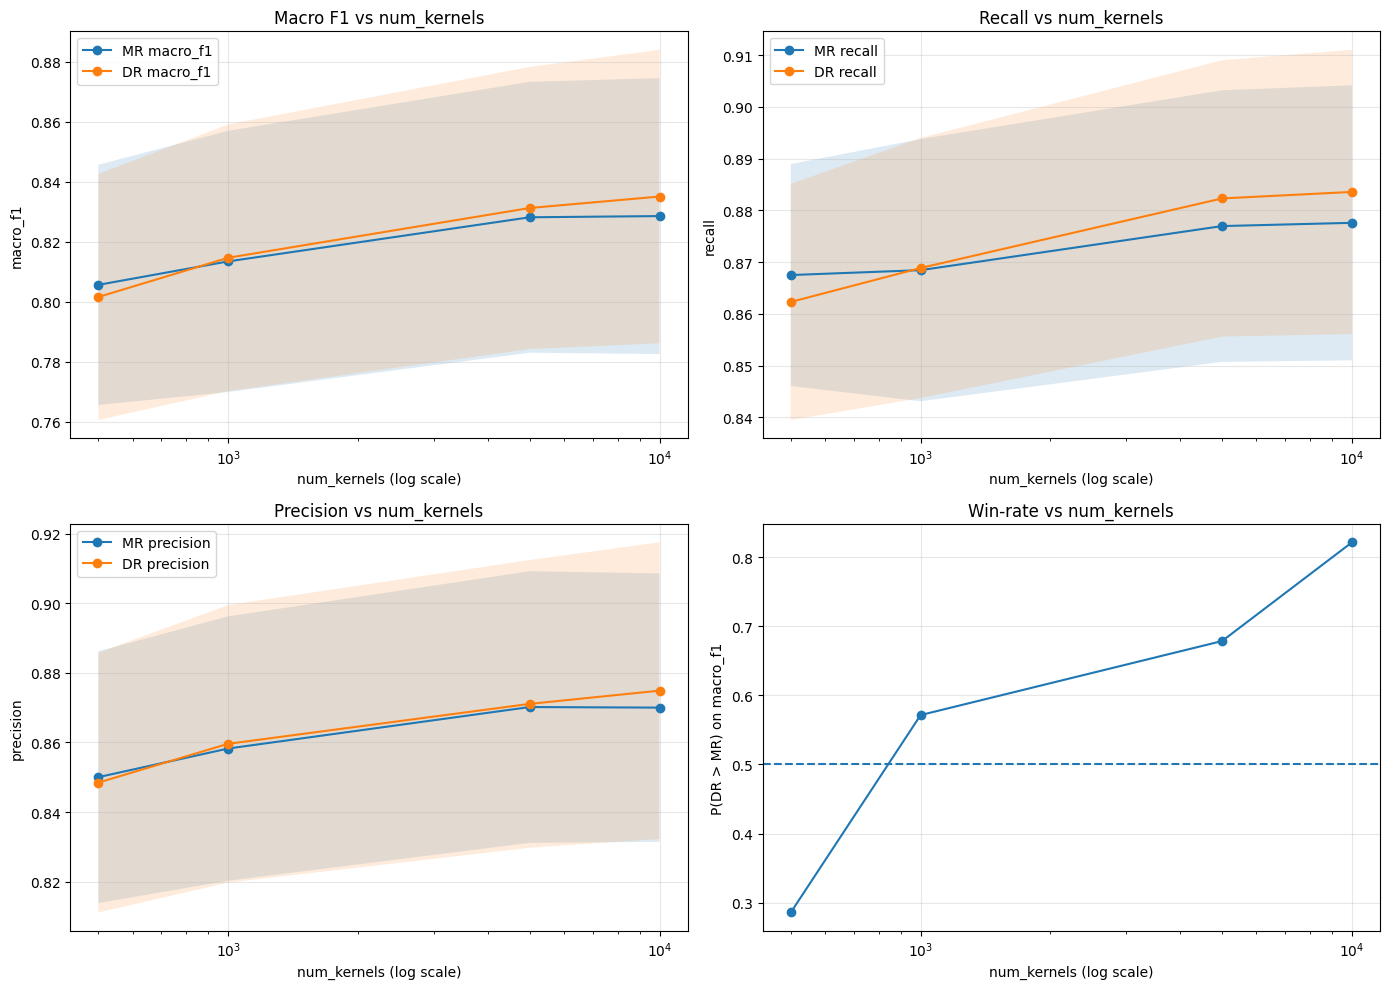

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Add comparison columns ---
df_kernel_cmp["dr_better_macro_f1"] = (df_kernel_cmp["macro_f1_dr"] > df_kernel_cmp["macro_f1_mr"]).astype(int)

# --- helper to compute mean/std curves ---
def metric_summary(metric):
    g = (
        df_kernel_cmp.groupby("num_kernels", as_index=False)
        .agg(
            mr_mean=(f"{metric}_mr", "mean"),
            dr_mean=(f"{metric}_dr", "mean"),
            mr_std=(f"{metric}_mr", "std"),
            dr_std=(f"{metric}_dr", "std"),
            n=("num_kernels", "count"),
        )
        .sort_values("num_kernels")
    )
    return g

# --- prepare summaries ---
g_macro = metric_summary("macro_f1")
g_recall = metric_summary("recall")
g_prec = metric_summary("precision")

win_rate = (
    df_kernel_cmp.groupby("num_kernels", as_index=False)
    .agg(dr_win_rate=("dr_better_macro_f1", "mean"), n=("dr_better_macro_f1", "count"))
    .sort_values("num_kernels")
)

# --- plotting ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plots = [
    ("macro_f1", g_macro, axes[0, 0], "Macro F1 vs num_kernels"),
    ("recall", g_recall, axes[0, 1], "Recall vs num_kernels"),
    ("precision", g_prec, axes[1, 0], "Precision vs num_kernels"),
]

# 3 metric plots
for metric, g, ax, title in plots:
    ax.plot(g["num_kernels"], g["mr_mean"], marker="o", label=f"MR {metric}")
    ax.plot(g["num_kernels"], g["dr_mean"], marker="o", label=f"DR {metric}")

    ax.fill_between(
        g["num_kernels"],
        g["mr_mean"] - g["mr_std"],
        g["mr_mean"] + g["mr_std"],
        alpha=0.15,
    )
    ax.fill_between(
        g["num_kernels"],
        g["dr_mean"] - g["dr_std"],
        g["dr_mean"] + g["dr_std"],
        alpha=0.15,
    )

    ax.set_xscale("log")
    ax.set_xlabel("num_kernels (log scale)")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

# win-rate plot (bottom-right)
ax = axes[1, 1]
ax.plot(win_rate["num_kernels"], win_rate["dr_win_rate"], marker="o")
ax.axhline(0.5, linestyle="--")
ax.set_xscale("log")
ax.set_xlabel("num_kernels (log scale)")
ax.set_ylabel("P(DR > MR) on macro_f1")
ax.set_title("Win-rate vs num_kernels")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
df_dr.head()

,drop_thermal_and_tof_options,use_raw_imus,use_physics_features,num_features,cebra_output_dims,train_dist,val_dist,num_kernels,acc,precision,recall,macro_f1,weighted_f1,cm
0,True,False,True,24,2,"Counter({1: 4090, 0: 2430})","Counter({1: 1023, 0: 608})",500,0.768240,0.815249,0.815249,0.752197,0.768240,[[419 189]\n [189 834]]
1,True,False,True,24,2,"Counter({1: 4090, 0: 2430})","Counter({1: 1023, 0: 608})",10000,0.798283,0.838867,0.839687,0.784248,0.798250,[[443 165]\n [164 859]]
2,True,False,True,24,2,"Counter({1: 4090, 0: 2430})","Counter({1: 1023, 0: 608})",5000,0.788473,0.834320,0.826979,0.774500,0.788783,[[440 168]\n [177 846]]
3,True,False,True,24,2,"Counter({1: 4090, 0: 2430})","Counter({1: 1023, 0: 608})",1000,0.778050,0.823702,0.822092,0.762844,0.778124,[[428 180]\n [182 841]]
4,True,True,False,11,2,"Counter({1: 4090, 0: 2430})","Counter({1: 1023, 0: 608})",500,0.727774,0.751958,0.844575,0.694120,0.719936,[[323 285]\n [159 864]]


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_dr = pd.read_csv("res/dr_classifxn.csv")
df_mr = pd.read_csv("res/mr_classifxn.csv")

# Ensure numeric
for df in [df_dr, df_mr]:
    df["num_features"] = df["num_features"].astype(int)
    df["cebra_output_dims"] = df["cebra_output_dims"].astype(int)
    df["num_kernels"] = df["num_kernels"].astype(int)

In [6]:
metric = "macro_f1"

mr_best = (
    df_mr.groupby(["num_features", "cebra_output_dims"], as_index=False)
    .agg(mr_best=(metric, "max"), mr_mean=(metric, "mean"), mr_n=(metric, "count"))
)

dr_best = (
    df_dr.groupby(["num_features", "cebra_output_dims"], as_index=False)
    .agg(dr_best=(metric, "max"), dr_mean=(metric, "mean"), dr_n=(metric, "count"))
)

df_feat_dim_cmp = pd.merge(mr_best, dr_best, on=["num_features", "cebra_output_dims"], how="inner")
df_feat_dim_cmp["delta_best"] = df_feat_dim_cmp["dr_best"] - df_feat_dim_cmp["mr_best"]
df_feat_dim_cmp["delta_mean"] = df_feat_dim_cmp["dr_mean"] - df_feat_dim_cmp["mr_mean"]

df_feat_dim_cmp.head()

,num_features,cebra_output_dims,mr_best,mr_mean,mr_n,dr_best,dr_mean,dr_n,delta_best,delta_mean
0,11,2,0.723884,0.709307,4,0.712112,0.702328,4,-0.011772,-0.006979
1,11,8,0.820803,0.801634,4,0.822503,0.803633,4,0.001700,0.001999
2,11,20,0.838296,0.808780,4,0.829181,0.815315,4,-0.009115,0.006535
3,11,32,0.824788,0.801092,4,0.822998,0.801631,4,-0.001790,0.000539
4,24,2,0.773410,0.763605,4,0.784248,0.768447,4,0.010838,0.004842


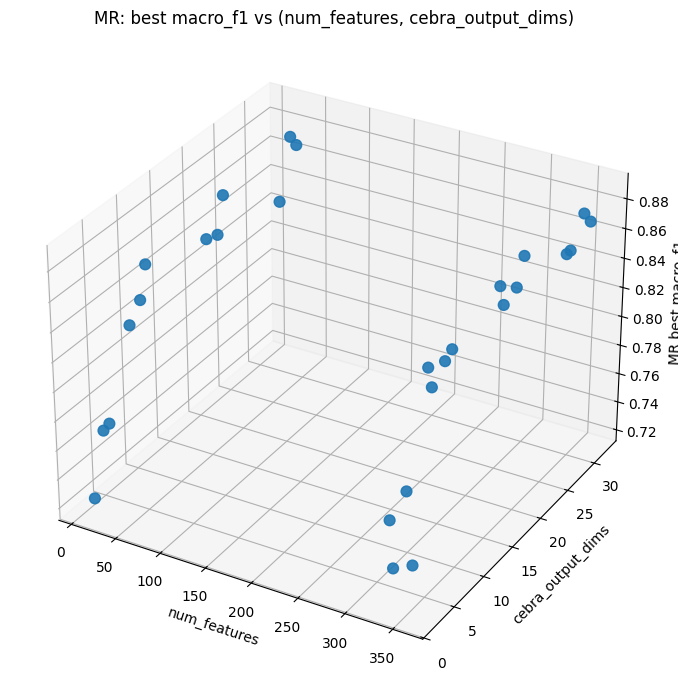

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df_feat_dim_cmp["num_features"],
    df_feat_dim_cmp["cebra_output_dims"],
    df_feat_dim_cmp["mr_best"],
    s=60,
    alpha=0.9,
)

ax.set_xlabel("num_features")
ax.set_ylabel("cebra_output_dims")
ax.set_zlabel("MR best macro_f1")
ax.set_title("MR: best macro_f1 vs (num_features, cebra_output_dims)")
plt.tight_layout()
plt.show()

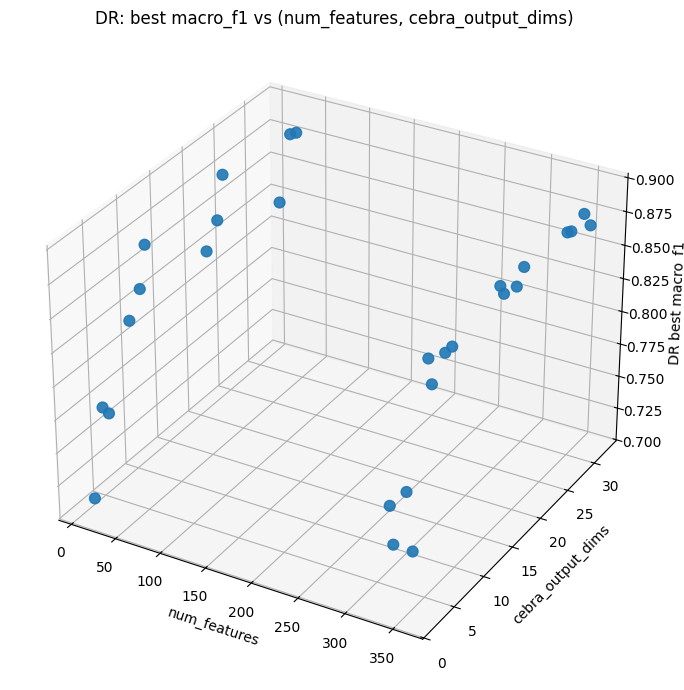

In [8]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df_feat_dim_cmp["num_features"],
    df_feat_dim_cmp["cebra_output_dims"],
    df_feat_dim_cmp["dr_best"],
    s=60,
    alpha=0.9,
)

ax.set_xlabel("num_features")
ax.set_ylabel("cebra_output_dims")
ax.set_zlabel("DR best macro_f1")
ax.set_title("DR: best macro_f1 vs (num_features, cebra_output_dims)")
plt.tight_layout()
plt.show()

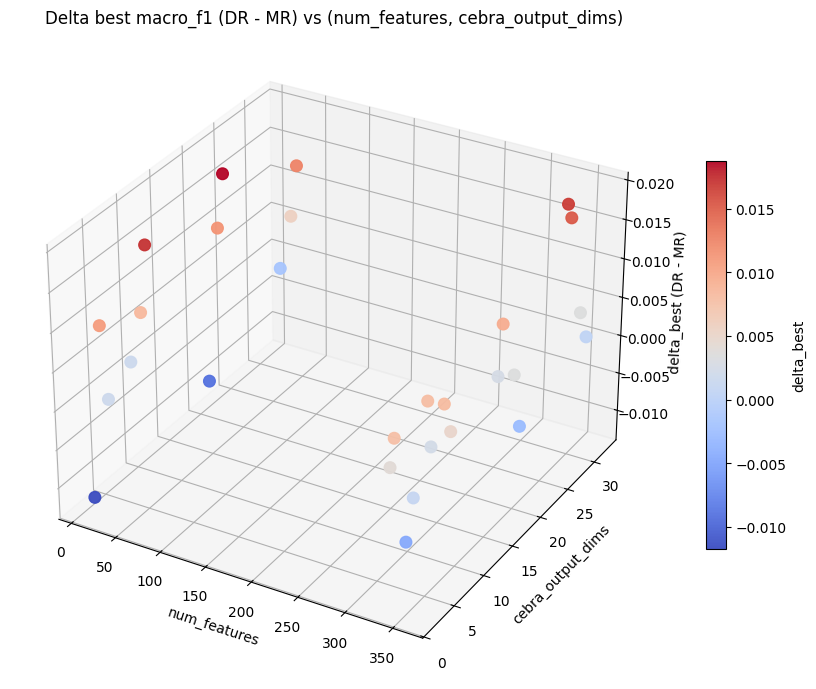

In [9]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    df_feat_dim_cmp["num_features"],
    df_feat_dim_cmp["cebra_output_dims"],
    df_feat_dim_cmp["delta_best"],
    s=70,
    alpha=0.95,
    c=df_feat_dim_cmp["delta_best"],
    cmap="coolwarm",
)

ax.set_xlabel("num_features")
ax.set_ylabel("cebra_output_dims")
ax.set_zlabel("delta_best (DR - MR)")
ax.set_title("Delta best macro_f1 (DR - MR) vs (num_features, cebra_output_dims)")
fig.colorbar(sc, ax=ax, shrink=0.6, label="delta_best")
plt.tight_layout()
plt.show()

In [22]:
def plot_heatmap(df, value_col, title, annot_fontsize=12):
    pivot = df.pivot(index="num_features", columns="cebra_output_dims", values=value_col)

    plt.figure(figsize=(8, 6))
    plt.imshow(pivot, aspect="auto", origin="lower")
    plt.colorbar(label=value_col)

    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)

    plt.xlabel("cebra_output_dims")
    plt.ylabel("num_features")
    plt.title(title)

    # annotate values (bigger font)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                plt.text(j, i, f"{val:.3f}", ha="center", va="center",
                         fontsize=annot_fontsize)

    plt.tight_layout()
    plt.show()

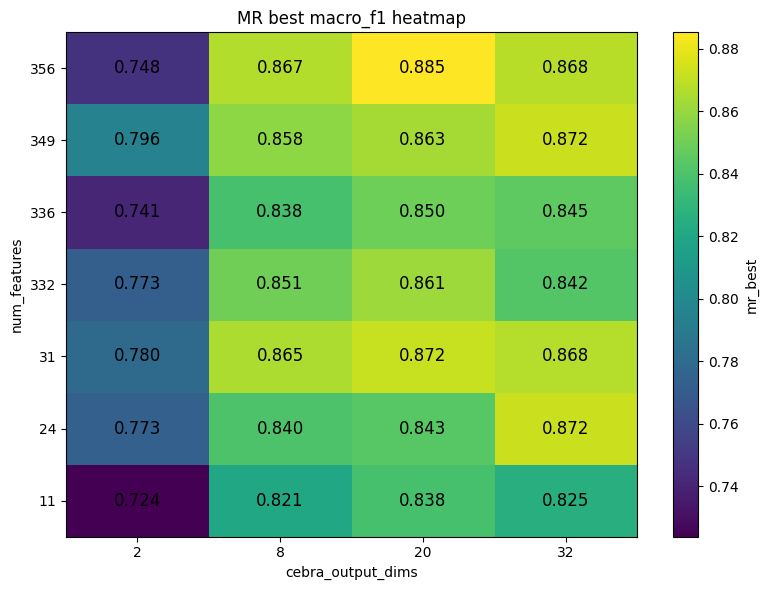

In [23]:
plot_heatmap(df_feat_dim_cmp, "mr_best", "MR best macro_f1 heatmap")

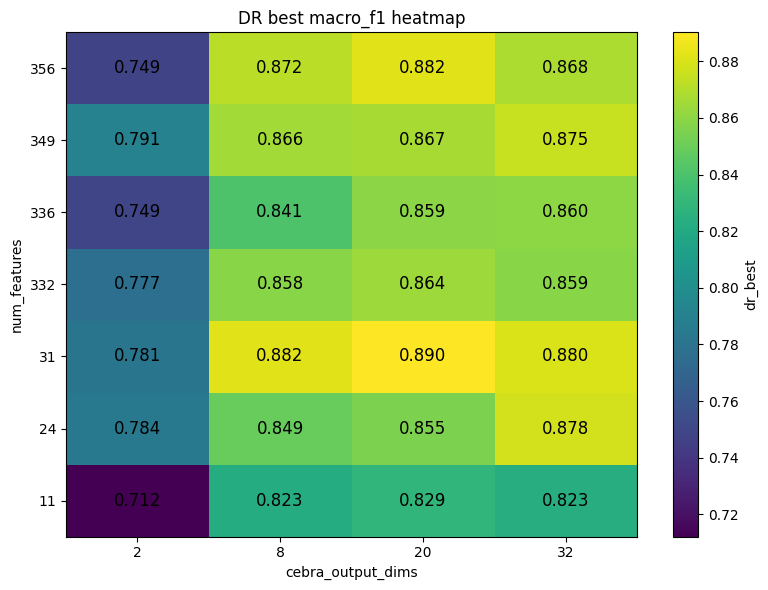

In [24]:
plot_heatmap(df_feat_dim_cmp, "dr_best", "DR best macro_f1 heatmap")

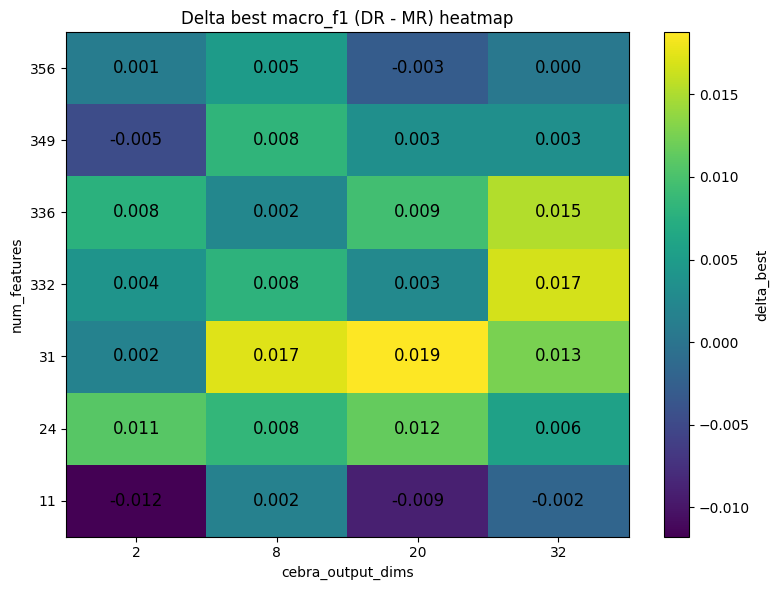

In [25]:
plot_heatmap(df_feat_dim_cmp, "delta_best", "Delta best macro_f1 (DR - MR) heatmap")

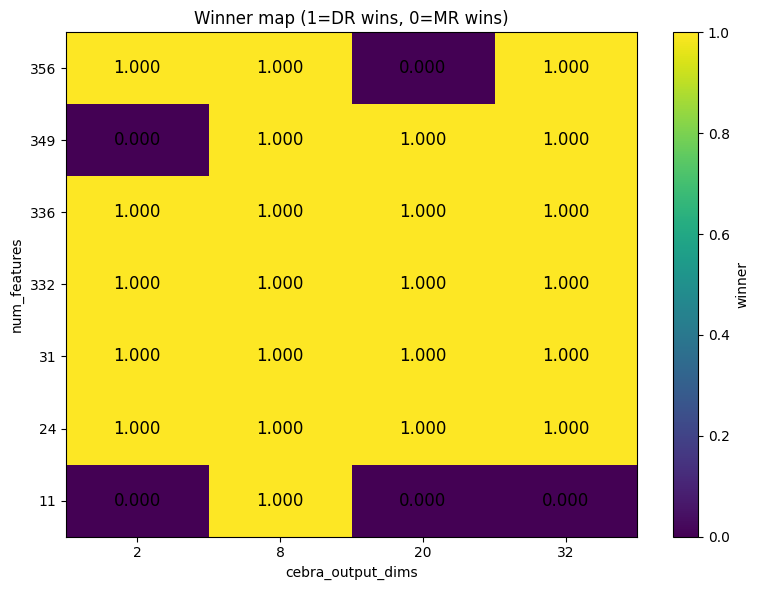

In [26]:
winner = df_feat_dim_cmp.copy()
winner["winner"] = np.where(winner["delta_best"] > 0, 1, 0)  # 1=DR wins, 0=MR wins

plot_heatmap(winner, "winner", "Winner map (1=DR wins, 0=MR wins)")

In [15]:
print("Top MR cases:")
print(df_feat_dim_cmp.sort_values("mr_best", ascending=False).head(10))

Top MR cases:
    num_features  cebra_output_dims   mr_best   mr_mean  mr_n   dr_best  \
26           356                 20  0.885222  0.869575     4  0.882295   
7             24                 32  0.872122  0.850135     4  0.877781   
23           349                 32  0.872097  0.855523     4  0.875479   
10            31                 20  0.871510  0.851704     4  0.890262   
27           356                 32  0.867863  0.861433     4  0.868313   
11            31                 32  0.867557  0.851503     4  0.880118   
25           356                  8  0.866688  0.856510     4  0.871673   
9             31                  8  0.865058  0.845150     4  0.882297   
22           349                 20  0.863304  0.852848     4  0.866759   
14           332                 20  0.861299  0.848813     4  0.863954   

     dr_mean  dr_n  delta_best  delta_mean  
26  0.873528     4   -0.002927    0.003952  
7   0.843229     4    0.005659   -0.006906  
23  0.860962     4    0.0

In [18]:
print("Biggest MR wins (delta_best):")
print(df_feat_dim_cmp.sort_values("delta_best", ascending=True).head(10))

Biggest MR wins (delta_best):
    num_features  cebra_output_dims   mr_best   mr_mean  mr_n   dr_best  \
0             11                  2  0.723884  0.709307     4  0.712112   
2             11                 20  0.838296  0.808780     4  0.829181   
20           349                  2  0.795524  0.789455     4  0.790800   
26           356                 20  0.885222  0.869575     4  0.882295   
3             11                 32  0.824788  0.801092     4  0.822998   
27           356                 32  0.867863  0.861433     4  0.868313   
24           356                  2  0.747546  0.741144     4  0.748650   
1             11                  8  0.820803  0.801634     4  0.822503   
8             31                  2  0.779507  0.773568     4  0.781253   
17           336                  8  0.838406  0.831836     4  0.840751   

     dr_mean  dr_n  delta_best  delta_mean  
0   0.702328     4   -0.011772   -0.006979  
2   0.815315     4   -0.009115    0.006535  
20  0.784

In [16]:
print("Top DR cases:")
print(df_feat_dim_cmp.sort_values("dr_best", ascending=False).head(10))

Top DR cases:
    num_features  cebra_output_dims   mr_best   mr_mean  mr_n   dr_best  \
10            31                 20  0.871510  0.851704     4  0.890262   
9             31                  8  0.865058  0.845150     4  0.882297   
26           356                 20  0.885222  0.869575     4  0.882295   
11            31                 32  0.867557  0.851503     4  0.880118   
7             24                 32  0.872122  0.850135     4  0.877781   
23           349                 32  0.872097  0.855523     4  0.875479   
25           356                  8  0.866688  0.856510     4  0.871673   
27           356                 32  0.867863  0.861433     4  0.868313   
22           349                 20  0.863304  0.852848     4  0.866759   
21           349                  8  0.857740  0.847485     4  0.865904   

     dr_mean  dr_n  delta_best  delta_mean  
10  0.861724     4    0.018753    0.010020  
9   0.854580     4    0.017239    0.009430  
26  0.873528     4   -0.0

In [17]:
print("Biggest DR wins (delta_best):")
print(df_feat_dim_cmp.sort_values("delta_best", ascending=False).head(10))

Biggest DR wins (delta_best):
    num_features  cebra_output_dims   mr_best   mr_mean  mr_n   dr_best  \
10            31                 20  0.871510  0.851704     4  0.890262   
9             31                  8  0.865058  0.845150     4  0.882297   
15           332                 32  0.841849  0.835825     4  0.858644   
19           336                 32  0.844974  0.840569     4  0.860163   
11            31                 32  0.867557  0.851503     4  0.880118   
6             24                 20  0.843447  0.827459     4  0.855037   
4             24                  2  0.773410  0.763605     4  0.784248   
18           336                 20  0.849573  0.842763     4  0.859054   
5             24                  8  0.840075  0.818858     4  0.848573   
21           349                  8  0.857740  0.847485     4  0.865904   

     dr_mean  dr_n  delta_best  delta_mean  
10  0.861724     4    0.018753    0.010020  
9   0.854580     4    0.017239    0.009430  
15  0.839

In [21]:
import pandas as pd

df_all = pd.concat([df_mr, df_dr], ignore_index=True)

cols = ["num_features", "drop_thermal_and_tof_options", "use_raw_imus", "use_physics_features"]

numfeat_table = (
    df_all[cols]
    .drop_duplicates()
    .sort_values(["num_features", "drop_thermal_and_tof_options", "use_raw_imus", "use_physics_features"])
    .reset_index(drop=True)
)

numfeat_table

,num_features,drop_thermal_and_tof_options,use_raw_imus,use_physics_features
0,11,True,True,False
1,24,True,False,True
2,31,True,True,True
3,332,False,False,False
4,336,False,True,False
5,349,False,False,True
6,356,False,True,True
